Connected to Python 3.14.2

1. Import Library

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt  # noqa

In [5]:
%pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Load Image

In [17]:
# Load gambar dengan error handling
blur_img = cv2.imread('images/blured.jpg')
contrast_img = cv2.imread('images/contrast.png')

if blur_img is None:
    raise ValueError("Gambar blur tidak dapat dimuat. Periksa path 'images/blured.jpg'")
if contrast_img is None:
    raise ValueError("Gambar kontras tidak dapat dimuat. Periksa path 'images/contrast.png'")

# Convert ke RGB untuk matplotlib
blur_img_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
contrast_img_rgb = cv2.cvtColor(contrast_img, cv2.COLOR_BGR2RGB)

3. SHARPENING (Fix Blur)

In [18]:
def unsharp_mask(image, sigma=2.0, strength=2.0):
    """
    Apply unsharp masking to sharpen the image.
    
    Parameters:
    - image: Input image (BGR)
    - sigma: Gaussian blur sigma
    - strength: Sharpening strength
    
    Returns:
    - Sharpened image
    """
    gaussian = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, strength, gaussian, -(strength - 1), 0)
    return sharpened

# Sharpening dengan unsharp masking
sharpen = unsharp_mask(blur_img, sigma=2.0, strength=2.0)

# Convert ke RGB
sharpen_rgb = cv2.cvtColor(sharpen, cv2.COLOR_BGR2RGB)

Visualisasi

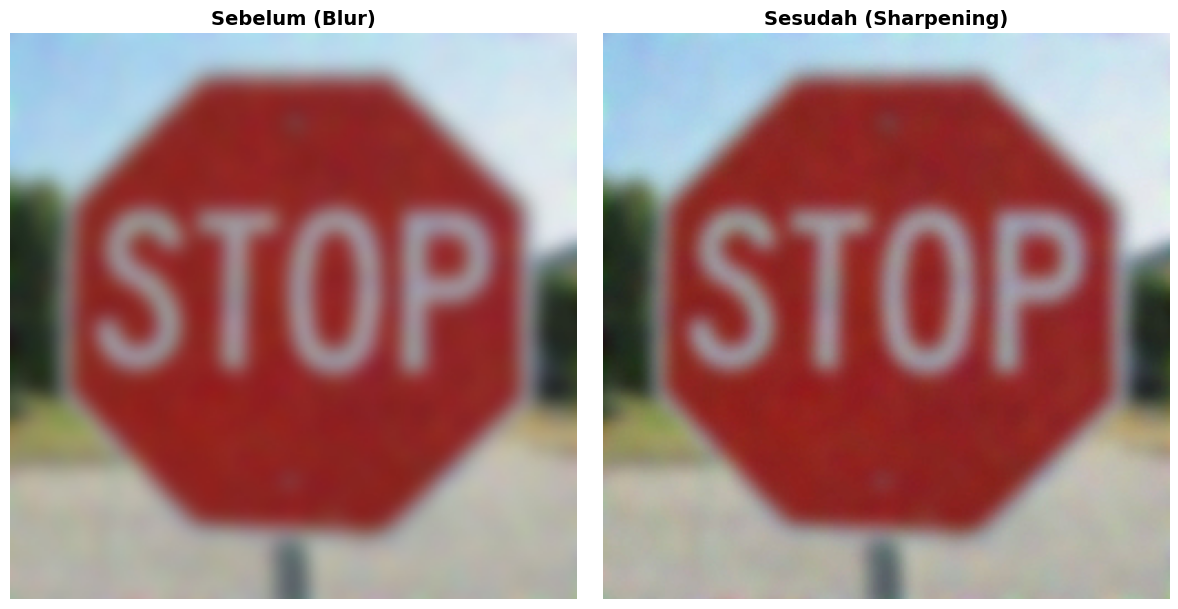

In [20]:
def plot_comparison(original, processed, title_original, title_processed, figsize=(12, 6)):
    """
    Plot before and after comparison.
    
    Parameters:
    - original: Original image (RGB)
    - processed: Processed image (RGB)
    - title_original: Title for original
    - title_processed: Title for processed
    - figsize: Figure size
    """
    plt.figure(figsize=figsize)
    
    plt.subplot(1, 2, 1)
    plt.title(title_original, fontsize=14, fontweight='bold')
    plt.imshow(original)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(title_processed, fontsize=14, fontweight='bold')
    plt.imshow(processed)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualisasi Sharpening
plot_comparison(blur_img_rgb, sharpen_rgb, "Sebelum (Blur)", "Sesudah (Sharpening)")

4. CLAHE (Fix Contrast)

In [19]:
def apply_clahe(image, clip_limit=4.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to enhance contrast.
    
    Parameters:
    - image: Input image (BGR)
    - clip_limit: Threshold for contrast limiting
    - tile_grid_size: Size of grid for histogram equalization
    
    Returns:
    - Enhanced image
    """
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    
    lab = cv2.merge((l2, a, b))
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return result

# Terapkan CLAHE
clahe_result = apply_clahe(contrast_img, clip_limit=4.0, tile_grid_size=(8, 8))

# Convert ke RGB
clahe_rgb = cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB)

Visualisasi

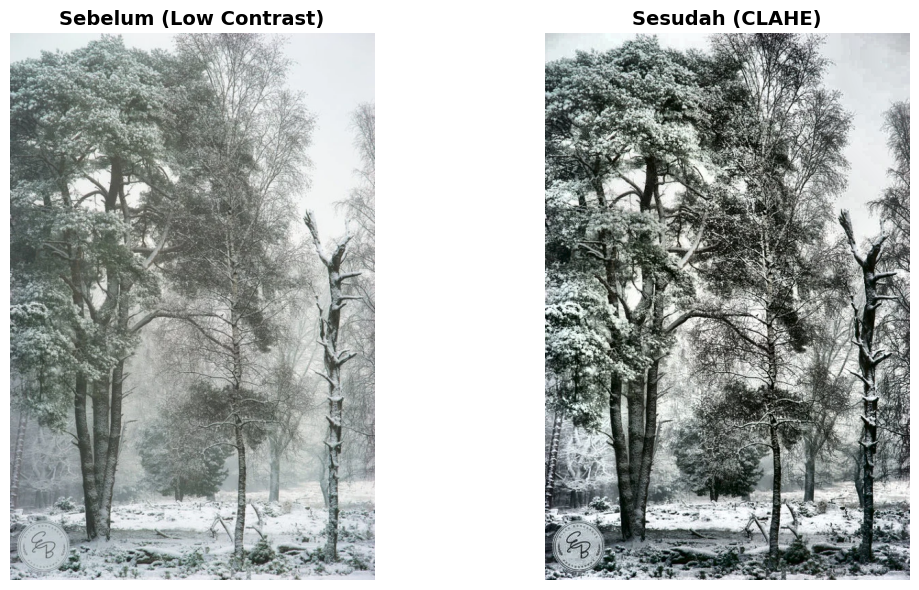

In [21]:
# Visualisasi CLAHE
plot_comparison(contrast_img_rgb, clahe_rgb, "Sebelum (Low Contrast)", "Sesudah (CLAHE)")

Hasil

In [22]:
import os

# Pastikan direktori hasil ada
os.makedirs('hasil', exist_ok=True)

# Simpan hasil dengan kualitas tinggi
success_sharpen = cv2.imwrite('hasil/hasil_sharpen.jpg', sharpen, [cv2.IMWRITE_JPEG_QUALITY, 95])
success_clahe = cv2.imwrite('hasil/hasil_clahe.jpg', clahe_result, [cv2.IMWRITE_JPEG_QUALITY, 95])

if success_sharpen and success_clahe:
    print("Gambar berhasil disimpan dengan kualitas tinggi.")
else:
    print("Gagal menyimpan gambar.")

Gambar berhasil disimpan dengan kualitas tinggi.


## Analisis

- Sharpening meningkatkan ketajaman tepi objek
- CLAHE meningkatkan kontras tanpa over-exposure
- Kedua metode efektif untuk perbaikan kualitas citra dengan masalah berbeda